In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)

plt.style.use('ggplot')

In [3]:
matches = pd.read_csv("ipl_matches_data.csv")

In [4]:
balls = pd.read_csv("ball_by_ball_data.csv")

In [5]:
teams = pd.read_csv("teams_data.csv")

In [6]:
players = pd.read_csv("players-data-updated.csv", encoding="latin-1")

In [7]:
matches.head()

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,overs,season,team_type,venue,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result,stage
0,335982,2008,6,Bangalore,18-04-2008,Indian Premier League,1.0,male,T20,T20,20,2008,club,M Chinnaswamy Stadium,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,field,Kolkata Knight Riders,140.0,NaN,46.0,win,NaN
1,1082591,2017,6,Hyderabad,05-04-2017,Indian Premier League,1.0,male,T20,T20,20,2017,club,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,15.0,win,NaN
2,1082592,2017,6,Pune,06-04-2017,Indian Premier League,2.0,male,T20,T20,20,2017,club,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Rising Pune Supergiant,Mumbai Indians,field,Rising Pune Supergiant,NaN,7.0,36.0,win,NaN
3,1082593,2017,6,Rajkot,07-04-2017,Indian Premier League,3.0,male,T20,T20,20,2017,club,Saurashtra Cricket Association Stadium,Kolkata Knight Riders,Gujarat Lions,Kolkata Knight Riders,field,Kolkata Knight Riders,NaN,10.0,57.0,win,NaN
4,1082594,2017,6,Indore,08-04-2017,Indian Premier League,4.0,male,T20,T20,20,2017,club,Holkar Cricket Stadium,Punjab Kings,Punjab Kings,Rising Pune Supergiant,field,Punjab Kings,NaN,6.0,71.0,win,NaN


In [9]:
balls.head()

,season_id,match_id,batter,bowler,non_striker,team_batting,team_bowling,over_number,ball_number,batter_runs,extras,total_runs,batsman_type,bowler_type,player_out,fielders_involved,is_wicket,is_wide_ball,is_no_ball,is_leg_bye,is_bye,is_penalty,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,wicket_kind,is_super_over,innings
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,Kolkata Knight Riders,Royal Challengers Bangalore,0,0,0,1,1,Left hand Bat,Right arm Medium,NaN,NaN,False,False,False,True,False,False,0,0,1,0,0,NaN,False,1
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,0,0,0,Right hand Bat,Right arm Medium,NaN,NaN,False,False,False,False,False,False,0,0,0,0,0,NaN,False,1
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0,1,1,Right hand Bat,Right arm Medium,NaN,NaN,False,True,False,False,False,False,1,0,0,0,0,NaN,False,1
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0,0,0,Right hand Bat,Right arm Medium,NaN,NaN,False,False,False,False,False,False,0,0,0,0,0,NaN,False,1
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0,0,0,Right hand Bat,Right arm Medium,NaN,NaN,False,False,False,False,False,False,0,0,0,0,0,NaN,False,1


In [10]:
players.head()

,player_id,player_name,bat_style,bowl_style,field_pos,player_full_name,player_name2,player_image
0,6730,Mohsin Khan,Left hand Bat,Left arm Medium fast,NaN,Mohsin Khan,Mohsin Khan,NaN
1,22,Rashid Khan,Right hand Bat,Legbreak Googly,,Rashid Khan Arman,Rashid Khan,https://www.espncricinfo.com/cricketers/rashid...
2,590,K Rabada,Left hand Bat,Right arm Fast,,Kagiso Rabada,Kagiso Rabada,https://ipl-stats-sports-mechanic.s3.ap-south-...
3,1424,SN Khan,Right hand Bat,Legbreak,,Sarfaraz Naushad Khan,Sarfaraz Naushad,NaN
4,963,MN Samuels,Right hand Bat,Right arm Offbreak,,Marlon Nathaniel Samuels,Marlon Nathaniel,NaN


In [11]:
teams.head()

,team_id,team_name,team_name_short,image_url
0,1,Royal Challengers Bangalore,RCB,https://documents.iplt20.com/ipl/RCB/Logos/Log...
1,2,Sunrisers Hyderabad,SRH,https://documents.iplt20.com/ipl/SRH/Logos/Log...
2,3,Mumbai Indians,MI,https://documents.iplt20.com/ipl/MI/Logos/Logo...
3,4,Rising Pune Supergiant,RPS,https://ipl-stats-sports-mechanic.s3.ap-south-...
4,5,Gujarat Lions,GL,https://ipl-stats-sports-mechanic.s3.ap-south-...


In [13]:
matches.shape

(1169, 24)

In [14]:
balls.shape

(278205, 30)

In [15]:
players.shape

(772, 8)

In [16]:
teams.shape

(16, 4)

In [17]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   match_id         1169 non-null   int64  
 1   season_id        1169 non-null   int64  
 2   balls_per_over   1169 non-null   int64  
 3   city             1118 non-null   str    
 4   match_date       1169 non-null   str    
 5   event_name       1169 non-null   str    
 6   match_number     1099 non-null   float64
 7   gender           1169 non-null   str    
 8   match_type       1169 non-null   str    
 9   format           1169 non-null   str    
 10  overs            1169 non-null   int64  
 11  season           1169 non-null   str    
 12  team_type        1169 non-null   str    
 13  venue            1169 non-null   str    
 14  toss_winner      1168 non-null   str    
 15  team1            1169 non-null   str    
 16  team2            1169 non-null   str    
 17  toss_decision    1168 non

In [18]:
balls.info()

<class 'pandas.DataFrame'>
RangeIndex: 278205 entries, 0 to 278204
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   season_id          278205 non-null  int64
 1   match_id           278205 non-null  int64
 2   batter             278205 non-null  str  
 3   bowler             278205 non-null  str  
 4   non_striker        278205 non-null  str  
 5   team_batting       278205 non-null  str  
 6   team_bowling       278205 non-null  str  
 7   over_number        278205 non-null  int64
 8   ball_number        278205 non-null  int64
 9   batter_runs        278205 non-null  int64
 10  extras             278205 non-null  int64
 11  total_runs         278205 non-null  int64
 12  batsman_type       278205 non-null  str  
 13  bowler_type        278205 non-null  str  
 14  player_out         13823 non-null   str  
 15  fielders_involved  13823 non-null   str  
 16  is_wicket          278205 non-null  bool 
 17  is

In [19]:
matches.isnull().sum().sort_values(ascending=False)

stage              1165
win_by_runs         638
win_by_wickets      554
match_number         70
city                 51
match_winner          8
player_of_match       8
toss_winner           1
toss_decision         1
event_name            0
gender                0
balls_per_over        0
match_id              0
season_id             0
match_date            0
match_type            0
team1                 0
venue                 0
team_type             0
season                0
format                0
overs                 0
team2                 0
result                0
dtype: int64

In [20]:
balls.isnull().sum().sort_values(ascending=False)

fielders_involved    264382
player_out           264382
wicket_kind          264382
batter                    0
season_id                 0
match_id                  0
team_bowling              0
over_number               0
ball_number               0
batter_runs               0
extras                    0
bowler                    0
non_striker               0
team_batting              0
bowler_type               0
batsman_type              0
total_runs                0
is_wicket                 0
is_no_ball                0
is_leg_bye                0
is_bye                    0
is_wide_ball              0
is_penalty                0
wide_ball_runs            0
leg_bye_runs              0
no_ball_runs              0
bye_runs                  0
penalty_runs              0
is_super_over             0
innings                   0
dtype: int64

In [21]:
matches['stage'] = matches['stage'].fillna('League Stage')

In [22]:
matches['win_by_runs'] = matches['win_by_runs'].fillna(0)

In [23]:
matches['win_by_wickets'] = matches['win_by_wickets'].fillna(0)

In [24]:
matches[matches['city'].isna()][['venue']]

,venue
181,Dubai International Cricket Stadium
183,Sharjah Cricket Stadium
184,Sharjah Cricket Stadium
186,Dubai International Cricket Stadium
188,Sharjah Cricket Stadium
190,Sharjah Cricket Stadium
192,Dubai International Cricket Stadium
195,Dubai International Cricket Stadium
197,Sharjah Cricket Stadium
198,Dubai International Cricket Stadium


In [25]:
venue_city = {
'Wankhede Stadium':'Mumbai',
'M. Chinnaswamy Stadium':'Bengaluru'
}

In [26]:
matches['city'] = matches['city'].fillna('Unknown')

In [27]:
matches['match_winner'] = matches['match_winner'].fillna('No Result')

In [28]:
matches['player_of_match'] = matches[
'player_of_match'
].fillna('No Award')

In [31]:
matches.fillna({'toss_decision': matches['toss_decision'].mode()[0]}, inplace=True)

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,overs,season,team_type,venue,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result,stage
0,335982,2008,6,Bangalore,18-04-2008,Indian Premier League,1.0,male,T20,T20,20,2008,club,M Chinnaswamy Stadium,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,field,Kolkata Knight Riders,140.0,0.0,46.0,win,League Stage
1,1082591,2017,6,Hyderabad,05-04-2017,Indian Premier League,1.0,male,T20,T20,20,2017,club,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,0.0,15.0,win,League Stage
2,1082592,2017,6,Pune,06-04-2017,Indian Premier League,2.0,male,T20,T20,20,2017,club,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Rising Pune Supergiant,Mumbai Indians,field,Rising Pune Supergiant,0.0,7.0,36.0,win,League Stage
3,1082593,2017,6,Rajkot,07-04-2017,Indian Premier League,3.0,male,T20,T20,20,2017,club,Saurashtra Cricket Association Stadium,Kolkata Knight Riders,Gujarat Lions,Kolkata Knight Riders,field,Kolkata Knight Riders,0.0,10.0,57.0,win,League Stage
4,1082594,2017,6,Indore,08-04-2017,Indian Premier League,4.0,male,T20,T20,20,2017,club,Holkar Cricket Stadium,Punjab Kings,Punjab Kings,Rising Pune Supergiant,field,Punjab Kings,0.0,6.0,71.0,win,League Stage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1164,1473509,2025,6,New Chandigarh,30-05-2025,Indian Premier League,NaN,male,Eliminator,T20,20,2025,club,Maharaja Yadavindra Singh International Cricke...,Mumbai Indians,Mumbai Indians,Gujarat Titans,bat,Mumbai Indians,20.0,0.0,25.0,win,Eliminator
1165,1473510,2025,6,Ahmedabad,01-06-2025,Indian Premier League,NaN,male,Qualifier 2,T20,20,2025,club,"Narendra Modi Stadium, Ahmedabad",Punjab Kings,Mumbai Indians,Punjab Kings,field,Punjab Kings,0.0,5.0,389.0,win,Qualifier 2
1166,1473511,2025,6,Ahmedabad,03-06-2025,Indian Premier League,NaN,male,Final,T20,20,2025,club,"Narendra Modi Stadium, Ahmedabad",Punjab Kings,Royal Challengers Bangalore,Punjab Kings,field,Royal Challengers Bangalore,6.0,0.0,28.0,win,Final
1167,1485779,2025,6,Jaipur,24-05-2025,Indian Premier League,66.0,male,T20,T20,20,2025,club,"Sawai Mansingh Stadium, Jaipur",Delhi Capitals,Punjab Kings,Delhi Capitals,field,Delhi Capitals,0.0,6.0,10070.0,win,League Stage


In [32]:
matches.duplicated().sum()

np.int64(0)

In [33]:
balls.duplicated().sum()

np.int64(0)

TEAM ANALYSIS
Total Matches Played

In [35]:
matches_played = pd.concat([
matches['team1'],
matches['team2']
]).value_counts()

matches_played.head(10)

Mumbai Indians                 277
Royal Challengers Bangalore    271
Sunrisers Hyderabad            271
Delhi Capitals                 266
Kolkata Knight Riders          265
Punjab Kings                   263
Chennai Super Kings            252
Rajasthan Royals               235
Gujarat Titans                  60
Lucknow Super Giants            58
Name: count, dtype: int64

In [36]:
team_wins = matches['match_winner'].value_counts()

team_wins.head(10)

match_winner
Mumbai Indians                 153
Chennai Super Kings            142
Kolkata Knight Riders          135
Royal Challengers Bangalore    133
Sunrisers Hyderabad            125
Punjab Kings                   123
Delhi Capitals                 121
Rajasthan Royals               116
Gujarat Titans                  37
Lucknow Super Giants            30
Name: count, dtype: int64

In [37]:
win_pct = round(
    (team_wins / matches_played) * 100,
    2
)

win_pct.sort_values(
    ascending=False
).head(10)

match_winner
Gujarat Titans                 61.67
Chennai Super Kings            56.35
Mumbai Indians                 55.23
Lucknow Super Giants           51.72
Kolkata Knight Riders          50.94
Rising Pune Supergiant         50.00
Rajasthan Royals               49.36
Royal Challengers Bangalore    49.08
Punjab Kings                   46.77
Sunrisers Hyderabad            46.13
Name: count, dtype: float64

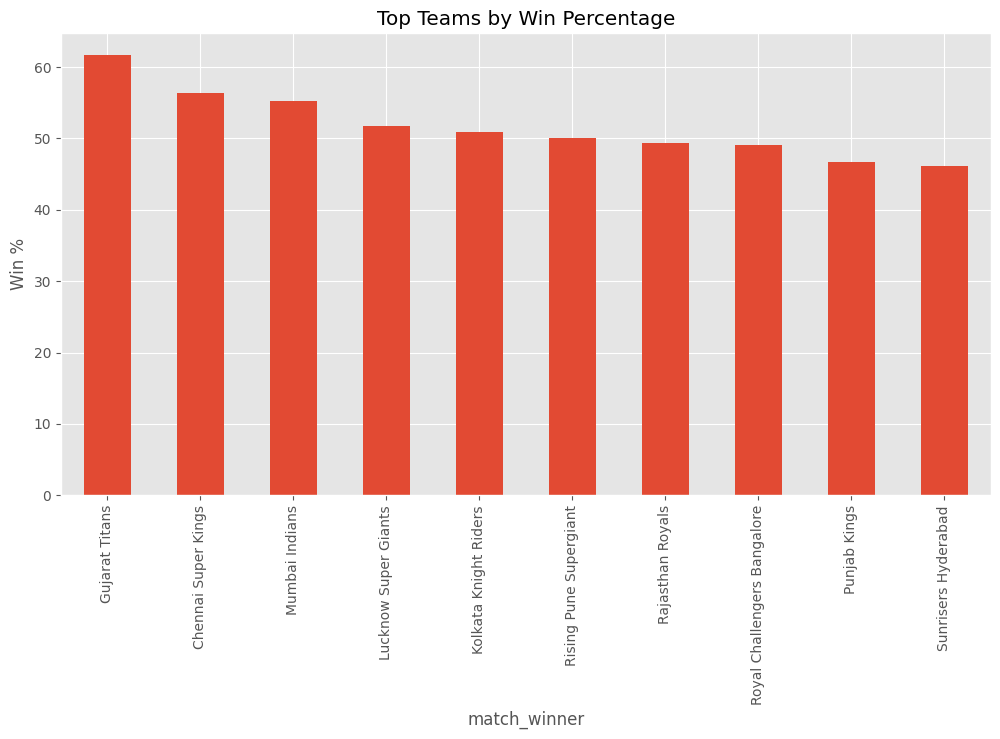

In [38]:
plt.figure(figsize=(12,6))

win_pct.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title("Top Teams by Win Percentage")

plt.ylabel("Win %")

plt.show()

In [39]:
team_summary = pd.DataFrame({
    'Matches Played':matches_played,
    'Wins':team_wins
})

team_summary['Win %'] = round(
    team_summary['Wins'] /
    team_summary['Matches Played'] * 100,
    2
)

team_summary.sort_values(
    'Wins',
    ascending=False
)

,Matches Played,Wins,Win %
Mumbai Indians,277.0,153,55.23
Chennai Super Kings,252.0,142,56.35
Kolkata Knight Riders,265.0,135,50.94
Royal Challengers Bangalore,271.0,133,49.08
Sunrisers Hyderabad,271.0,125,46.13
Punjab Kings,263.0,123,46.77
Delhi Capitals,266.0,121,45.49
Rajasthan Royals,235.0,116,49.36
Gujarat Titans,60.0,37,61.67
Lucknow Super Giants,58.0,30,51.72


In [40]:
top_runs = balls.groupby(
    'batter'
)['batter_runs'].sum()

top_runs.sort_values(
    ascending=False
).head(20)

batter
V Kohli           8671
RG Sharma         7048
S Dhawan          6769
DA Warner         6567
SK Raina          5536
MS Dhoni          5439
KL Rahul          5235
AB de Villiers    5181
AM Rahane         5032
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
F du Plessis      4773
SV Samson         4704
AT Rayudu         4348
SA Yadav          4311
G Gambhir         4217
JC Buttler        4121
MK Pandey         3951
SR Watson         3880
Name: batter_runs, dtype: int64

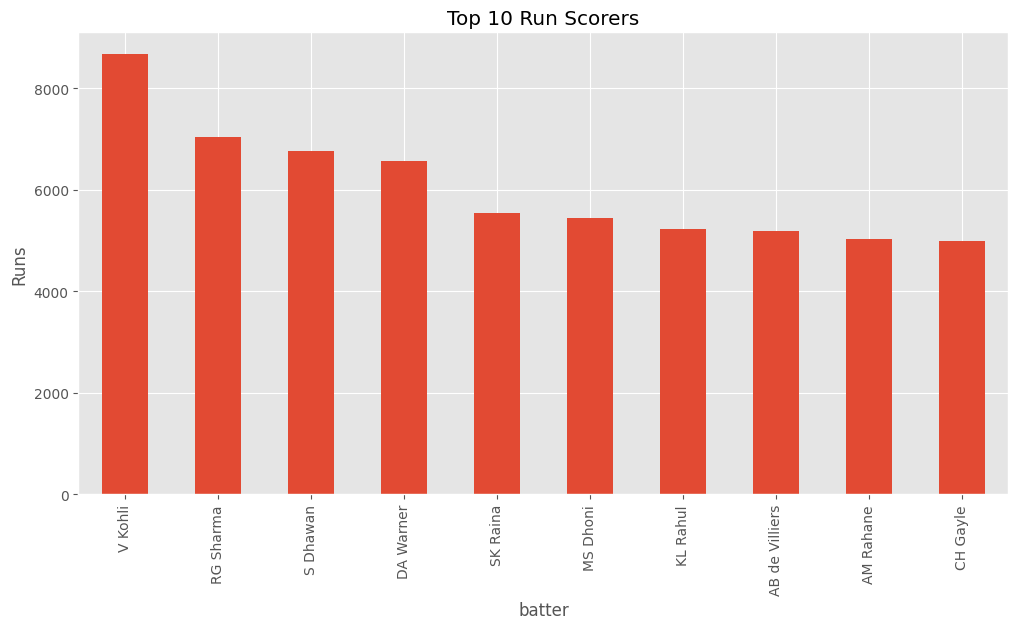

In [41]:
plt.figure(figsize=(12,6))

top_runs.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title("Top 10 Run Scorers")

plt.ylabel("Runs")

plt.show()

In [42]:
sixes = balls[
    balls['batter_runs']==6
]['batter'].value_counts()

sixes.head(10)

batter
CH Gayle          359
RG Sharma         303
V Kohli           292
MS Dhoni          264
AB de Villiers    253
DA Warner         236
KA Pollard        224
AD Russell        223
SV Samson         219
KL Rahul          208
Name: count, dtype: int64

In [43]:
fours = balls[
    balls['batter_runs']==4
]['batter'].value_counts()

fours.head(10)

batter
V Kohli       774
S Dhawan      768
DA Warner     663
RG Sharma     640
AM Rahane     515
SK Raina      506
G Gambhir     492
RV Uthappa    481
KD Karthik    466
SA Yadav      454
Name: count, dtype: int64

In [48]:
runs = balls.groupby(
    'batter'
)['batter_runs'].sum()

balls_faced = balls.groupby(
    'batter'
).size()

batting = pd.DataFrame({
    'Runs':runs,
    'Balls':balls_faced
})
batting

,Runs,Balls
batter,,
A Ashish Reddy,280,196
A Badoni,963,740
A Chandila,4,7
A Chopra,53,75
A Choudhary,25,20
...,...,...
Yashpal Singh,47,67
Younis Khan,3,7
Yudhvir Singh,22,16


In [49]:
batting['Strike Rate'] = round(
    batting['Runs'] /
    batting['Balls'] * 100,
    2
)
batting

,Runs,Balls,Strike Rate
batter,,,
A Ashish Reddy,280,196,142.86
A Badoni,963,740,130.14
A Chandila,4,7,57.14
A Chopra,53,75,70.67
A Choudhary,25,20,125.00
...,...,...,...
Yashpal Singh,47,67,70.15
Younis Khan,3,7,42.86
Yudhvir Singh,22,16,137.50


In [50]:
batting = batting[
    batting['Runs'] >= 500
]
batting

,Runs,Balls,Strike Rate
batter,,,
A Badoni,963,740,130.14
A Symonds,974,781,124.71
AB de Villiers,5181,3487,148.58
AC Gilchrist,2069,1555,133.05
AD Mathews,724,599,120.87
...,...,...,...
Washington Sundar,511,426,119.95
Y Venugopal Rao,985,865,113.87
YBK Jaiswal,2166,1454,148.97


In [47]:
batting.sort_values(
    'Strike Rate',
    ascending=False
).head(20)

,Runs,Balls,Strike Rate
batter,,,
Priyansh Arya,545,310,175.81
PD Salt,1056,623,169.50
AD Russell,2655,1626,163.28
H Klaasen,1480,907,163.18
TM Head,1146,706,162.32
TH David,846,524,161.45
T Stubbs,711,442,160.86
N Pooran,2293,1433,160.01
Abhishek Sharma,1816,1167,155.61


In [54]:
wickets = balls[
    balls['is_wicket']==1
]
wickets

,season_id,match_id,batter,bowler,non_striker,team_batting,team_bowling,over_number,ball_number,batter_runs,extras,total_runs,batsman_type,bowler_type,player_out,fielders_involved,is_wicket,is_wide_ball,is_no_ball,is_leg_bye,is_bye,is_penalty,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,wicket_kind,is_super_over,innings
33,2008,335982,SC Ganguly,Z Khan,BB McCullum,Kolkata Knight Riders,Royal Challengers Bangalore,5,1,0,0,0,Left hand Bat,Left arm Fast medium,SC Ganguly,"[""JH Kallis""]",True,False,False,False,False,False,0,0,0,0,0,caught,False,1
74,2008,335982,RT Ponting,JH Kallis,BB McCullum,Kolkata Knight Riders,Royal Challengers Bangalore,12,0,0,0,0,Right hand Bat,Right arm Fast medium,RT Ponting,"[""P Kumar""]",True,False,False,False,False,False,0,0,0,0,0,caught,False,1
106,2008,335982,DJ Hussey,AA Noffke,BB McCullum,Kolkata Knight Riders,Royal Challengers Bangalore,17,0,0,0,0,Right hand Bat,Right arm Fast medium,DJ Hussey,"[""CL White""]",True,False,False,False,False,False,0,0,0,0,0,caught,False,1
131,2008,335982,R Dravid,I Sharma,W Jaffer,Royal Challengers Bangalore,Kolkata Knight Riders,1,0,0,0,0,Right hand Bat,Right arm Fast medium,R Dravid,[null],True,False,False,False,False,False,0,0,0,0,0,bowled,False,2
138,2008,335982,V Kohli,AB Dinda,W Jaffer,Royal Challengers Bangalore,Kolkata Knight Riders,2,1,0,0,0,Right hand Bat,Right arm Medium fast,V Kohli,[null],True,False,False,False,False,False,0,0,0,0,0,bowled,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278080,2025,1485779,M Jansen,Mustafizur Rahman,MP Stoinis,Punjab Kings,Delhi Capitals,19,2,0,0,0,Right hand Bat,Left arm Fast medium,M Jansen,"[""T Stubbs""]",True,False,False,False,False,False,0,0,0,0,0,caught,False,1
278116,2025,1485779,KL Rahul,M Jansen,F du Plessis,Delhi Capitals,Punjab Kings,5,2,0,0,0,Right hand Bat,Left arm Medium fast,KL Rahul,"[""Shashank Singh""]",True,False,False,False,False,False,0,0,0,0,0,caught,False,2
278123,2025,1485779,F du Plessis,Harpreet Brar,KK Nair,Delhi Capitals,Punjab Kings,6,3,0,0,0,Right hand Bat,Slow Left arm Orthodox,F du Plessis,"[""Priyansh Arya""]",True,False,False,False,False,False,0,0,0,0,0,caught,False,2
278144,2025,1485779,Sediqullah Atal,P Dubey,KK Nair,Delhi Capitals,Punjab Kings,10,0,0,0,0,Left hand Bat,Legbreak Googly,Sediqullah Atal,"[""Arshdeep Singh""]",True,False,False,False,False,False,0,0,0,0,0,caught,False,2


In [53]:
top_wickets = wickets.groupby(
    'bowler'
).size()

top_wickets.sort_values(
    ascending=False
).head(20)

bowler
YS Chahal          229
B Kumar            213
SP Narine          212
DJ Bravo           207
R Ashwin           205
JJ Bumrah          203
PP Chawla          201
SL Malinga         188
A Mishra           183
RA Jadeja          179
HV Patel           168
Rashid Khan        166
Sandeep Sharma     163
UT Yadav           163
Harbhajan Singh    161
TA Boult           151
Mohammed Shami     150
MM Sharma          149
AR Patel           137
AD Russell         133
dtype: int64

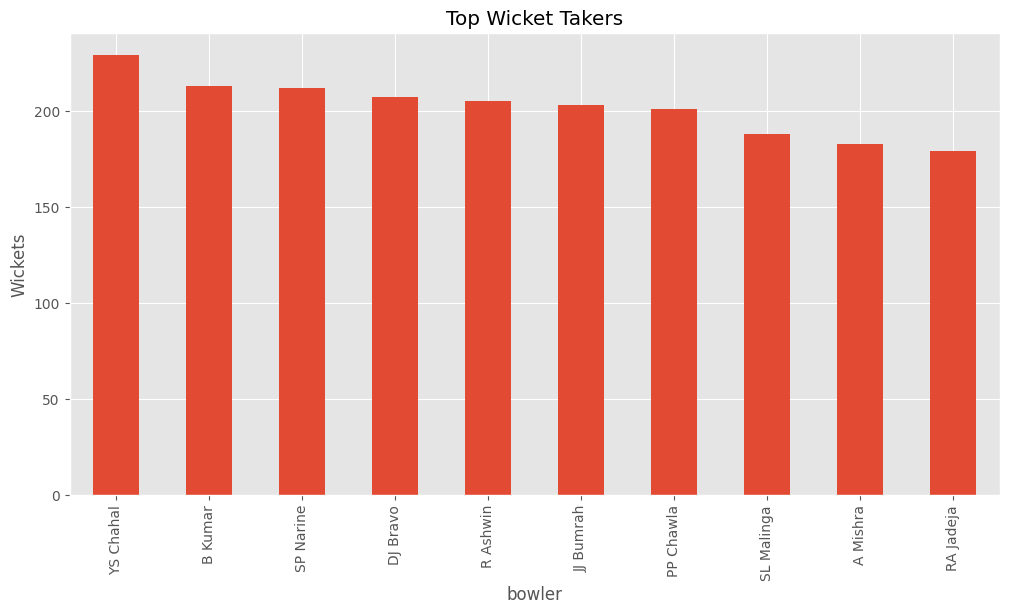

In [55]:
plt.figure(figsize=(12,6))

top_wickets.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title("Top Wicket Takers")

plt.ylabel("Wickets")

plt.show()

In [57]:
runs_given = balls.groupby(
    'bowler'
)['total_runs'].sum()
runs_given

bowler
A Ashish Reddy     400
A Badoni            50
A Chandila         245
A Choudhary        144
A Dananjaya         47
                  ... 
Yash Thakur        782
Yudhvir Singh      257
Yuvraj Singh      1091
Z Khan            2860
Zeeshan Ansari     334
Name: total_runs, Length: 550, dtype: int64

In [59]:
balls_bowled = balls.groupby(
    'bowler'
).size()
balls_bowled

bowler
A Ashish Reddy     270
A Badoni            35
A Chandila         234
A Choudhary        108
A Dananjaya         25
                  ... 
Yash Thakur        475
Yudhvir Singh      145
Yuvraj Singh       882
Z Khan            2276
Zeeshan Ansari     209
Length: 550, dtype: int64

In [60]:
bowling = pd.DataFrame({
    'Runs':runs_given,
    'Balls':balls_bowled
})
bowling

,Runs,Balls
bowler,,
A Ashish Reddy,400,270
A Badoni,50,35
A Chandila,245,234
A Choudhary,144,108
A Dananjaya,47,25
...,...,...
Yash Thakur,782,475
Yudhvir Singh,257,145
Yuvraj Singh,1091,882


In [62]:
bowling['Overs'] = round(
    bowling['Balls']/6,
    1
)
bowling

,Runs,Balls,Overs
bowler,,,
A Ashish Reddy,400,270,45.0
A Badoni,50,35,5.8
A Chandila,245,234,39.0
A Choudhary,144,108,18.0
A Dananjaya,47,25,4.2
...,...,...,...
Yash Thakur,782,475,79.2
Yudhvir Singh,257,145,24.2
Yuvraj Singh,1091,882,147.0


In [63]:
bowling['Economy'] = round(
    bowling['Runs'] /
    bowling['Overs'],
    2
)
bowling

,Runs,Balls,Overs,Economy
bowler,,,,
A Ashish Reddy,400,270,45.0,8.89
A Badoni,50,35,5.8,8.62
A Chandila,245,234,39.0,6.28
A Choudhary,144,108,18.0,8.00
A Dananjaya,47,25,4.2,11.19
...,...,...,...,...
Yash Thakur,782,475,79.2,9.87
Yudhvir Singh,257,145,24.2,10.62
Yuvraj Singh,1091,882,147.0,7.42


In [65]:
bowling = bowling[
    bowling['Balls'] >= 300
]
bowling

,Runs,Balls,Overs,Economy
bowler,,,,
A Kumble,1089,983,163.8,6.65
A Mishra,4193,3444,574.0,7.30
A Mithun,477,312,52.0,9.17
A Nehra,2537,1974,329.0,7.71
A Nortje,1701,1142,190.3,8.94
...,...,...,...,...
YS Chahal,5112,3905,650.8,7.85
Yash Dayal,1412,920,153.3,9.21
Yash Thakur,782,475,79.2,9.87


In [66]:
matches['venue'].value_counts().head(20)

venue
Eden Gardens                                                             77
Wankhede Stadium                                                         73
M Chinnaswamy Stadium                                                    65
Feroz Shah Kotla                                                         60
Wankhede Stadium, Mumbai                                                 52
Rajiv Gandhi International Stadium, Uppal                                49
MA Chidambaram Stadium, Chepauk                                          48
Sawai Mansingh Stadium                                                   47
Dubai International Cricket Stadium                                      46
Punjab Cricket Association Stadium, Mohali                               35
MA Chidambaram Stadium, Chepauk, Chennai                                 34
Narendra Modi Stadium, Ahmedabad                                         33
Sheikh Zayed Stadium                                                     29
Sharja

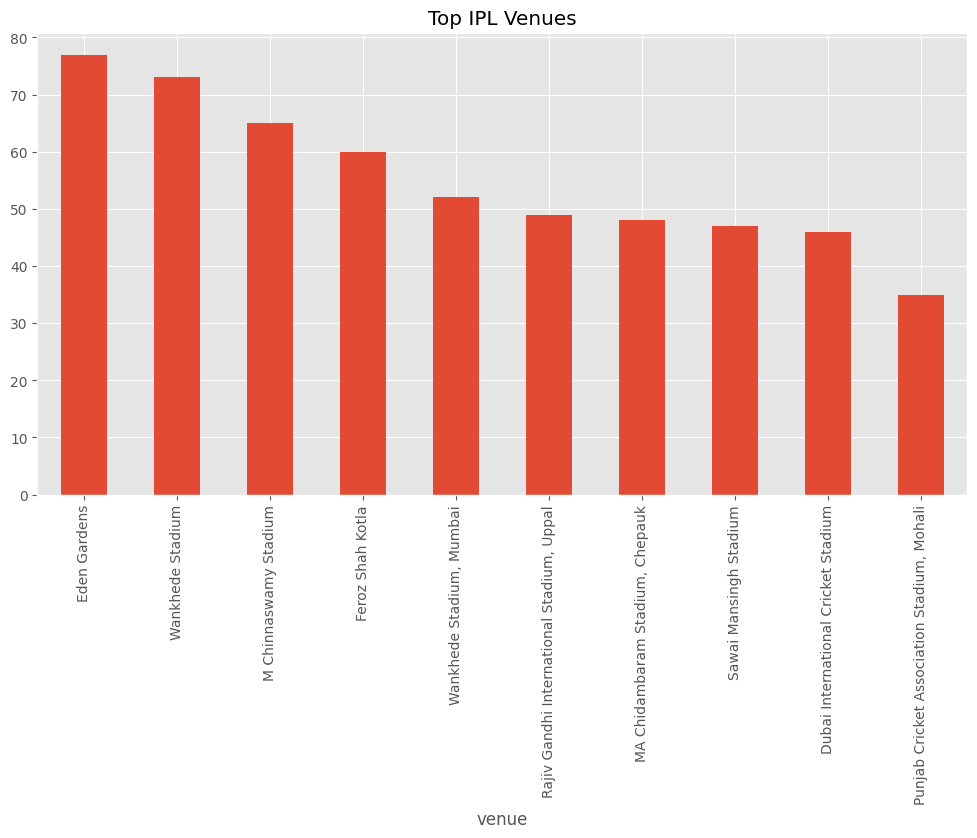

In [67]:
plt.figure(figsize=(12,6))

matches['venue'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top IPL Venues")

plt.show()

In [69]:
balls = balls.merge(
    matches[['match_id','venue']],
    on='match_id',
    how='left'
)
balls

,season_id,match_id,batter,bowler,non_striker,team_batting,team_bowling,over_number,ball_number,batter_runs,extras,total_runs,batsman_type,bowler_type,player_out,fielders_involved,is_wicket,is_wide_ball,is_no_ball,is_leg_bye,is_bye,is_penalty,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,wicket_kind,is_super_over,innings,venue_x,venue_y
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,Kolkata Knight Riders,Royal Challengers Bangalore,0,0,0,1,1,Left hand Bat,Right arm Medium,NaN,NaN,False,False,False,True,False,False,0,0,1,0,0,NaN,False,1,M Chinnaswamy Stadium,M Chinnaswamy Stadium
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,0,0,0,Right hand Bat,Right arm Medium,NaN,NaN,False,False,False,False,False,False,0,0,0,0,0,NaN,False,1,M Chinnaswamy Stadium,M Chinnaswamy Stadium
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0,1,1,Right hand Bat,Right arm Medium,NaN,NaN,False,True,False,False,False,False,1,0,0,0,0,NaN,False,1,M Chinnaswamy Stadium,M Chinnaswamy Stadium
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0,0,0,Right hand Bat,Right arm Medium,NaN,NaN,False,False,False,False,False,False,0,0,0,0,0,NaN,False,1,M Chinnaswamy Stadium,M Chinnaswamy Stadium
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0,0,0,Right hand Bat,Right arm Medium,NaN,NaN,False,False,False,False,False,False,0,0,0,0,0,NaN,False,1,M Chinnaswamy Stadium,M Chinnaswamy Stadium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278200,2025,1485779,T Stubbs,Arshdeep Singh,Sameer Rizvi,Delhi Capitals,Punjab Kings,18,5,4,0,4,Right hand Bat,Left arm Medium fast,NaN,NaN,False,False,False,False,False,False,0,0,0,0,0,NaN,False,2,"Sawai Mansingh Stadium, Jaipur","Sawai Mansingh Stadium, Jaipur"
278201,2025,1485779,Sameer Rizvi,MP Stoinis,T Stubbs,Delhi Capitals,Punjab Kings,19,0,0,1,1,Right hand Bat,Right arm Medium,NaN,NaN,False,True,False,False,False,False,1,0,0,0,0,NaN,False,2,"Sawai Mansingh Stadium, Jaipur","Sawai Mansingh Stadium, Jaipur"
278202,2025,1485779,Sameer Rizvi,MP Stoinis,T Stubbs,Delhi Capitals,Punjab Kings,19,1,1,0,1,Right hand Bat,Right arm Medium,NaN,NaN,False,False,False,False,False,False,0,0,0,0,0,NaN,False,2,"Sawai Mansingh Stadium, Jaipur","Sawai Mansingh Stadium, Jaipur"
278203,2025,1485779,T Stubbs,MP Stoinis,Sameer Rizvi,Delhi Capitals,Punjab Kings,19,2,1,0,1,Right hand Bat,Right arm Medium,NaN,NaN,False,False,False,False,False,False,0,0,0,0,0,NaN,False,2,"Sawai Mansingh Stadium, Jaipur","Sawai Mansingh Stadium, Jaipur"


In [75]:
balls = balls.merge(matches[['match_id', 'venue']], on='match_id', how='left')

# Now you can safely group by venue!
venue_scores = balls.groupby('venue')['total_runs'].mean()

# Multiply by 120 for a projected 20-over score
projected_t20_scores = venue_scores * 120

# Show the top 20 highest-scoring venues
projected_t20_scores.sort_values(ascending=False).head(20)


venue
Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh    210.967742
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam         193.021807
Himachal Pradesh Cricket Association Stadium, Dharamsala                   189.473684
Eden Gardens, Kolkata                                                      188.678414
Arun Jaitley Stadium, Delhi                                                186.425180
Rajiv Gandhi International Stadium, Uppal, Hyderabad                       185.297686
M Chinnaswamy Stadium, Bengaluru                                           184.893383
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh           184.523612
Sawai Mansingh Stadium, Jaipur                                             180.860534
Narendra Modi Stadium, Ahmedabad                                           178.296100
M.Chinnaswamy Stadium                                                      176.084717
Holkar Cricket Stadium                          

In [76]:
toss_impact = (
    matches['toss_winner']
    ==
    matches['match_winner']
).mean()*100

print(toss_impact)

51.15483319076134


In [78]:
season_matches = matches[
    'season'
].value_counts().sort_index()

season_matches

season
2008       58
2009       57
2010       60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
2025       74
Name: count, dtype: int64

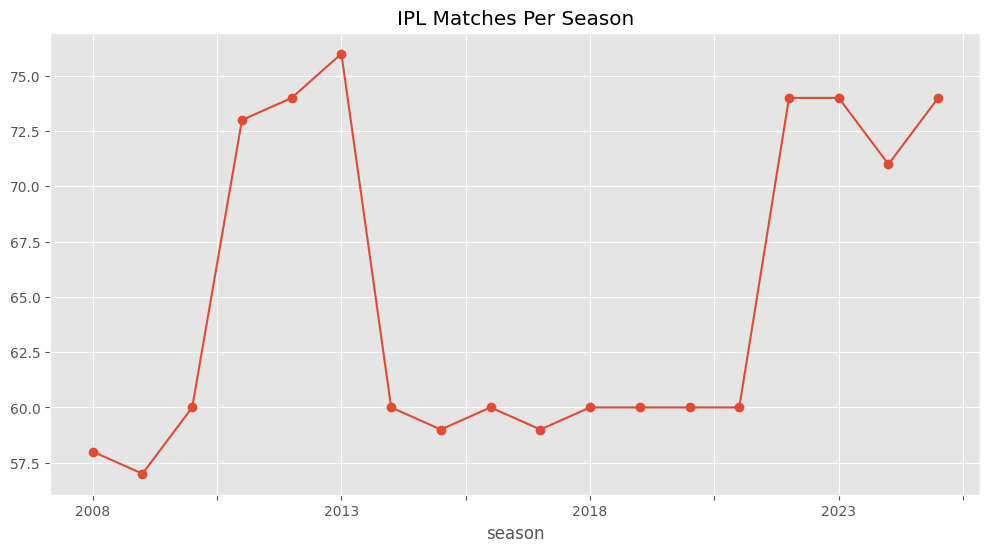

In [79]:
plt.figure(figsize=(12,6))

season_matches.plot(
    marker='o'
)

plt.title(
    "IPL Matches Per Season"
)

plt.show()

In [8]:
season_runs = balls.groupby(
    ['season_id','batter']
)['batter_runs'].sum().reset_index()

orange_cap = season_runs.loc[
    season_runs.groupby(
        'season_id'
    )['batter_runs'].idxmax()
]

orange_cap

,season_id,batter,batter_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641


In [9]:
boundary_runs = balls[
    balls['batter_runs'].isin([4,6])
].groupby('batter')['batter_runs'].sum()

total_runs = balls.groupby(
    'batter'
)['batter_runs'].sum()

boundary_pct = (
    boundary_runs /
    total_runs * 100
).round(2)

boundary_pct.sort_values(
    ascending=False
).head(20)

batter
VRV Singh          100.00
RS Sodhi           100.00
KT Maphaka         100.00
Liton Das          100.00
GD McGrath         100.00
A Tomar            100.00
BA Bhatt           100.00
P Chopra           100.00
AA Kulkarni         88.89
L Ronchi            88.24
J Fraser-McGurk     87.27
Umar Gul            87.18
J Arunkumar         86.96
V Suryavanshi       85.71
Ankit Soni          85.71
MDKJ Perera         85.71
R Bishnoi           84.21
MA Wood             83.33
ER Dwivedi          83.33
Urvil Patel         82.35
Name: batter_runs, dtype: float64

In [12]:
match_runs = balls.groupby(
    ['match_id','batter']
)['batter_runs'].sum().reset_index()

consistency = match_runs.groupby(
    'batter'
)['batter_runs'].std()

consistency.sort_values().head(20)

batter
Akash Madhwal       0.000000
SB Joshi            0.000000
R Minz              0.000000
CRD Fernando        0.000000
RP Meredith         0.000000
JP Behrendorff      0.000000
S Ladda             0.000000
KK Ahmed            0.516398
A Singh             0.547723
Fazalhaq Farooqi    0.577350
Shoaib Ahmed        0.577350
KP Appanna          0.577350
BE Hendricks        0.707107
P Parameswaran      0.707107
LE Plunkett         0.707107
JE Taylor           0.707107
PP Ojha             0.834210
VG Arora            0.866025
BB Sran             0.975900
GC Viljoen          1.000000
Name: batter_runs, dtype: float64

In [13]:
wickets = balls[
    balls['is_wicket']==1
]

season_wickets = wickets.groupby(
    ['season_id','bowler']
).size().reset_index(
    name='wickets'
)

purple_cap = season_wickets.loc[
    season_wickets.groupby(
        'season_id'
    )['wickets'].idxmax()
]

purple_cap

,season_id,bowler,wickets
77,2008,Sohail Tanvir,24
157,2009,RP Singh,26
248,2010,PP Ojha,22
375,2011,SL Malinga,30
447,2012,M Morkel,30
519,2013,DJ Bravo,34
650,2014,MM Sharma,26
708,2015,DJ Bravo,28
791,2016,B Kumar,24
879,2017,B Kumar,28


In [14]:
wickets_taken = wickets.groupby(
    'bowler'
).size()

balls_bowled = balls.groupby(
    'bowler'
).size()

bowling_sr = (
    balls_bowled /
    wickets_taken
).round(2)

bowling_sr.sort_values().head(20)

bowler
AC Gilchrist        1.00
D Brevis            3.00
Sachin Baby         3.33
AM Rahane           6.00
SS Mundhe           7.00
LA Carseldine       7.00
Ramandeep Singh     7.50
DAJ Bracewell       8.33
A Badoni            8.75
L Ablish            9.00
Shoaib Akhtar       9.20
T Stubbs            9.25
W O'Rourke         10.67
D du Preez         10.75
Umar Gul           10.93
MG Bracewell       11.00
Sohail Tanvir      11.04
MA Wood            11.55
E Malinga          11.79
V Kaverappa        12.00
dtype: float64

In [15]:
powerplay = balls[
    balls['over_number']<=6
]

In [16]:
powerplay.groupby(
    'batter'
)['batter_runs'].sum().sort_values(
    ascending=False
).head(20)

batter
S Dhawan        3776
DA Warner       3648
V Kohli         3535
AM Rahane       2833
RG Sharma       2694
CH Gayle        2668
G Gambhir       2539
F du Plessis    2520
KL Rahul        2471
RV Uthappa      2353
Q de Kock       2127
PA Patel        2058
Shubman Gill    1949
JC Buttler      1879
SK Raina        1873
V Sehwag        1785
BB McCullum     1746
SV Samson       1721
M Vijay         1711
SR Watson       1656
Name: batter_runs, dtype: int64

In [17]:
powerplay[
    powerplay['is_wicket']==1
].groupby(
    'bowler'
).size().sort_values(
    ascending=False
).head(20)

bowler
B Kumar            85
TA Boult           73
DL Chahar          70
Sandeep Sharma     69
UT Yadav           63
I Sharma           63
Z Khan             59
R Ashwin           56
Mohammed Shami     56
P Kumar            48
DS Kulkarni        47
Mohammed Siraj     47
Harbhajan Singh    46
A Nehra            45
JJ Bumrah          44
MM Sharma          42
SL Malinga         41
KK Ahmed           39
M Morkel           39
JA Morkel          38
dtype: int64

In [18]:
death = balls[
    balls['over_number']>=16
]

In [19]:
death.groupby(
    'batter'
)['batter_runs'].sum().sort_values(
    ascending=False
).head(20)

batter
MS Dhoni          2936
KA Pollard        1708
KD Karthik        1565
RA Jadeja         1532
AB de Villiers    1421
HH Pandya         1241
RG Sharma         1176
AD Russell        1134
V Kohli           1121
DA Miller         1061
AT Rayudu          877
YK Pathan          858
DJ Bravo           800
SO Hetmyer         794
AR Patel           788
MP Stoinis         720
JP Duminy          712
R Tewatia          705
RR Pant            696
SK Raina           664
Name: batter_runs, dtype: int64

In [20]:
death[
    death['is_wicket']==1
].groupby(
    'bowler'
).size().sort_values(
    ascending=False
).head(20)

bowler
DJ Bravo          115
SL Malinga        104
B Kumar           101
JJ Bumrah          98
HV Patel           82
MM Sharma          72
SP Narine          69
Mohammed Shami     69
Sandeep Sharma     61
CH Morris          61
R Vinay Kumar      58
TA Boult           57
JD Unadkat         57
UT Yadav           56
K Rabada           56
AD Russell         55
A Nehra            54
Arshdeep Singh     53
RP Singh           53
SN Thakur          50
dtype: int64

In [23]:
matches['won_after_toss'] = (
    matches['toss_winner']
    ==
    matches['match_winner']
)
matches['won_after_toss'].mean() * 100


np.float64(51.15483319076134)

In [24]:
# Step 1: Merge the venue column into your balls dataset
balls_with_venue = balls.merge(matches[['match_id', 'venue']], on='match_id', how='left')

# Step 2: Get total runs per match using the new merged dataset
venue_score = balls_with_venue.groupby(
    ['match_id', 'venue']
)['total_runs'].sum().reset_index()

# Step 3: Get the average runs per venue sorted highest to lowest
average_runs = venue_score.groupby(
    'venue'
)['total_runs'].mean().sort_values(
    ascending=False
)

print(average_runs)


venue
Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh    436.000000
Himachal Pradesh Cricket Association Stadium, Dharamsala                   390.000000
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam         387.250000
Arun Jaitley Stadium, Delhi                                                384.130435
Eden Gardens, Kolkata                                                      372.434783
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh           371.200000
M Chinnaswamy Stadium, Bengaluru                                           368.894737
Rajiv Gandhi International Stadium, Uppal, Hyderabad                       361.736842
Sawai Mansingh Stadium, Jaipur                                             358.529412
Narendra Modi Stadium, Ahmedabad                                           356.727273
Brabourne Stadium                                                          348.100000
Punjab Cricket Association IS Bindra Stadium    

In [25]:
matches['matchup'] = (
    matches['team1']
    + ' vs '
    + matches['team2']
)

In [27]:
matches[
    matches['matchup'].str.contains(
        'Chennai Super Kings'
    )
]

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,overs,season,team_type,venue,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result,stage,won_after_toss,matchup
60,1136561,2018,6,Mumbai,07-04-2018,Indian Premier League,1.0,male,T20,T20,20,2018,club,Wankhede Stadium,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,field,Chennai Super Kings,NaN,1.0,1393.0,win,NaN,True,Mumbai Indians vs Chennai Super Kings
64,1136565,2018,6,Chennai,10-04-2018,Indian Premier League,5.0,male,T20,T20,20,2018,club,MA Chidambaram Stadium,Chennai Super Kings,Kolkata Knight Riders,Chennai Super Kings,field,Chennai Super Kings,NaN,5.0,178.0,win,NaN,True,Kolkata Knight Riders vs Chennai Super Kings
71,1136572,2018,6,Chandigarh,15-04-2018,Indian Premier League,12.0,male,T20,T20,20,2018,club,Punjab Cricket Association IS Bindra Stadium,Chennai Super Kings,Punjab Kings,Chennai Super Kings,field,Punjab Kings,4.0,NaN,1.0,win,NaN,False,Punjab Kings vs Chennai Super Kings
76,1136577,2018,6,Pune,20-04-2018,Indian Premier League,17.0,male,T20,T20,20,2018,club,Maharashtra Cricket Association Stadium,Rajasthan Royals,Chennai Super Kings,Rajasthan Royals,field,Chennai Super Kings,64.0,NaN,5.0,win,NaN,False,Chennai Super Kings vs Rajasthan Royals
79,1136580,2018,6,Hyderabad,22-04-2018,Indian Premier League,20.0,male,T20,T20,20,2018,club,Rajiv Gandhi International Stadium,Sunrisers Hyderabad,Chennai Super Kings,Sunrisers Hyderabad,field,Chennai Super Kings,4.0,NaN,27.0,win,NaN,False,Chennai Super Kings vs Sunrisers Hyderabad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143,1473486,2025,6,Chennai,30-04-2025,Indian Premier League,49.0,male,T20,T20,20,2025,club,"MA Chidambaram Stadium, Chepauk, Chennai",Punjab Kings,Chennai Super Kings,Punjab Kings,field,Punjab Kings,NaN,4.0,389.0,win,NaN,True,Chennai Super Kings vs Punjab Kings
1146,1473489,2025,6,Bengaluru,03-05-2025,Indian Premier League,52.0,male,T20,T20,20,2025,club,"M Chinnaswamy Stadium, Bengaluru",Chennai Super Kings,Royal Challengers Bangalore,Chennai Super Kings,field,Royal Challengers Bangalore,2.0,NaN,6761.0,win,NaN,False,Royal Challengers Bangalore vs Chennai Super K...
1151,1473494,2025,6,Kolkata,07-05-2025,Indian Premier League,57.0,male,T20,T20,20,2025,club,"Eden Gardens, Kolkata",Kolkata Knight Riders,Kolkata Knight Riders,Chennai Super Kings,bat,Chennai Super Kings,NaN,2.0,8809.0,win,NaN,False,Kolkata Knight Riders vs Chennai Super Kings
1155,1473500,2025,6,Delhi,20-05-2025,Indian Premier League,62.0,male,T20,T20,20,2025,club,"Arun Jaitley Stadium, Delhi",Rajasthan Royals,Chennai Super Kings,Rajasthan Royals,field,Rajasthan Royals,NaN,6.0,9371.0,win,NaN,True,Chennai Super Kings vs Rajasthan Royals


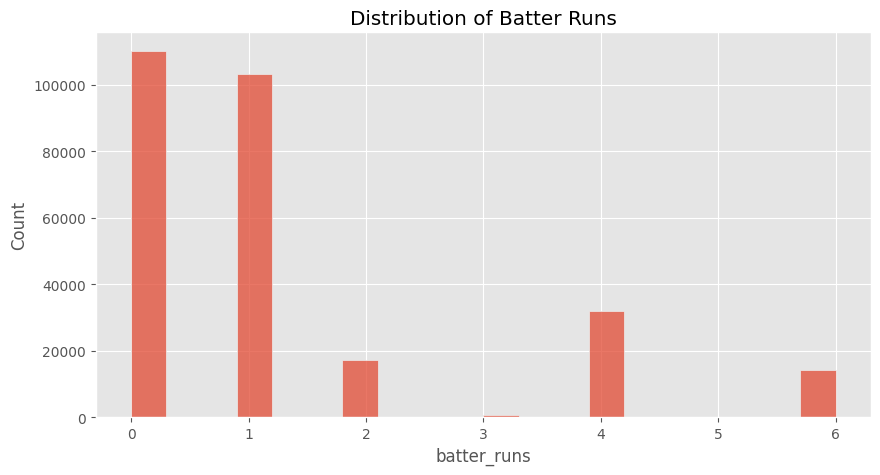

In [32]:
plt.figure(figsize=(10,5))
sns.histplot(balls['batter_runs'], bins=20)
plt.title('Distribution of Batter Runs')
plt.show()

In [33]:
team_scores = balls.groupby(
    ['match_id','team_batting']
)['total_runs'].sum()

team_scores.describe()

count    2333.000000
mean      160.429919
std        33.492682
min         2.000000
25%       140.000000
50%       161.000000
75%       182.000000
max       287.000000
Name: total_runs, dtype: float64